### Enable importing modules from the parent project directory

In [87]:
import sys
import os
sys.path.append(os.path.abspath(".."))  # Adds project root

### Importing necessary libraries

In [88]:
import pandas as pd  # Data manipulation and DataFrame support
import numpy as np  # Numerical computing with arrays
import math  # Basic mathematical functions
import matplotlib.pyplot as plt  # Plotting and visualization
from sklearn.metrics import mean_squared_error, mean_absolute_error  # Evaluation metrics
from statistics import mode  # Compute statistical mode
import folium  # Interactive maps (leaflet.js-based)
from folium.plugins import MarkerCluster  # Cluster markers on maps
from scipy.stats import pearsonr  # Pearson correlation calculation
from sklearn.preprocessing import StandardScaler  # Z-score normalization
from sklearn.preprocessing import MinMaxScaler  # Scale features to 0–1 range
from tqdm import tqdm  # Progress bars for loops
from prophet import Prophet  # Facebook Prophet time series forecasting
import random  # Random number generation
from sklearn.impute import SimpleImputer  # Basic missing value imputation
from typing import Dict  # Type hinting for dictionaries
import seaborn as sns  # Statistical data visualization
from sklearn.impute import SimpleImputer  # (Duplicate) Basic imputation again
from IPython.display import display, HTML  # Pretty HTML display in notebooks
from sklearn.decomposition import PCA  # Principal Component Analysis (dimensionality reduction)
from sklearn.preprocessing import StandardScaler  # (Duplicate) Z-score scaling
from statsmodels.tsa.holtwinters import ExponentialSmoothing  # Time series smoothing & forecasting
from sklearn.ensemble import RandomForestRegressor  # Random Forest for regression tasks
from sklearn.inspection import permutation_importance  # Feature importance via permutation
import warnings  # Control warning messages
warnings.filterwarnings("ignore")  # Suppress warnings (useful in notebooks)
from prophet.plot import plot_plotly, plot_components_plotly  # Plotting Prophet results
from prophet.diagnostics import cross_validation, performance_metrics  # Prophet diagnostics tools

In [89]:
from typing import List, Tuple  # Type hinting for lists and tuples

from Algorithms.CDREC import CDRec  # Collaborative Denoising for matrix completion
from Algorithms.TKCM import TKCM  # Top-k Case Matching (basic version)
from Algorithms.TKCM_Weighted import TKCM_Weighted  # TKCM with similarity-based weighting
from Algorithms.DynaMMO import DynaMMo  # Dynamic Matrix Modeling for time series imputation
from Algorithms.SoftImpute import SoftImpute  # Low-rank matrix completion using soft-thresholding
from Algorithms.SVDImpute import IterativeSVD  # Iterative SVD-based matrix imputation
from Algorithms.trmf import TRMFImputer  # Temporal Regularized Matrix Factorization
from Algorithms.ST_MVL import ST_MVL  # Space-Time Matrix-Vector Learning
from Algorithms.TKCM_PLUS import TKCM_PLUS  # TKCM variant with alpha–beta blending, also using Target series known values to fill the missing values
from Algorithms.TKCM_PRO import TKCM_PRO  # Pro version of TKCM with anchor filtering, here averaging the refrence to fill the missing values


### Loading the Dataset

In [90]:

# # Load dataset
mountain_df = pd.read_csv("D:\\Thesis\\Project\\Data\\mountain_data.csv")

# Count different types of missingness
stats = {
    "Total Rows": len(mountain_df),
    "Total Columns": len(mountain_df.columns),
    "Zero Values": (mountain_df == 0).sum().sum(),
    "NaN Values": mountain_df.isna().sum().sum(),
    "Blank Strings": (mountain_df == "").sum().sum(),
    "Unknown Strings": (mountain_df.applymap(lambda x: isinstance(x, str) and x.strip().lower() == "unknown")).sum().sum()
}

# Return as DataFrame
stats_df = pd.DataFrame(list(stats.items()), columns=["Metric", "Value"])
stats_df


,Metric,Value
0,Total Rows,2785482
1,Total Columns,6
2,Zero Values,96350
3,NaN Values,0
4,Blank Strings,0
5,Unknown Strings,0


#### Displaying the first 5 rows of the data

In [91]:
mountain_df.head()

,station_code,sensor_code,description_it,unit,timestamp,value
0,45200SF,LT,Temperatura dell´aria,°C,2025-01-01 00:00:00,-2.1
1,45200SF,LT,Temperatura dell´aria,°C,2024-12-31 23:30:00,-0.8
2,45200SF,LT,Temperatura dell´aria,°C,2024-12-31 23:00:00,-2.2
3,45200SF,LT,Temperatura dell´aria,°C,2024-12-31 22:30:00,-0.6
4,45200SF,LT,Temperatura dell´aria,°C,2024-12-31 22:00:00,-1.0


### Displaying column-wise metadata


In [92]:
mountain_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2785482 entries, 0 to 2785481
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   station_code    object 
 1   sensor_code     object 
 2   description_it  object 
 3   unit            object 
 4   timestamp       object 
 5   value           float64
dtypes: float64(1), object(5)
memory usage: 127.5+ MB


### describe() provide us with statistical summary of numeric columns


In [93]:
mountain_df.describe()

,value
count,2.785482e+06
mean,5.304164e+01
std,8.350127e+01
min,-2.460000e+01
25%,1.200000e+00
50%,8.200000e+00
75%,7.700000e+01
max,3.660000e+02


In [94]:
# Preview data
print("🔍 Shape:", mountain_df.shape)

🔍 Shape: (2785482, 6)


In [95]:
# Check which columns are non-numeric
print("🧠 Columns in the file:\n", mountain_df.dtypes)

🧠 Columns in the file:
 station_code       object
sensor_code        object
description_it     object
unit               object
timestamp          object
value             float64
dtype: object


### Checking all the unique sensor codes i have in this dataset

In [96]:
unique_values = mountain_df['sensor_code'].unique()
unique_values

array(['LT', 'WR', 'WG', 'WG.BOE', 'LF', 'HS', 'N'], dtype=object)

### checking unique similar station_codes

In [97]:
unique_values1 = mountain_df['station_code'].unique()
unique_values1

array(['45200SF', '82500WS', '45100WS', '00700WS', '00390SF', '06040WS',
       '06090SF', '35100WS', '50400WS', '50360SF', '61690SF', '61720WS',
       '20720WS', '20690SF', '91210WS', '91180SF', '24300SF', '78480SF',
       '15000SF', '34200WS', '31810SF', '66000WS', '66100SF', '80100SF',
       '90005SF', '15050WS', '07740WS', '15590SF', '01080SF', '20050SF',
       '35205SF', '24170WS', '53200SF', '42830SF', '62270SF', '02700SF'],
      dtype=object)

### Looking at the descriptions of the sensor what is meaning of those sensor codes

In [98]:
unique_values2 = mountain_df['description_it'].unique()
unique_values2

array(['Temperatura dell´aria', 'Direzione del vento',
       'Velocità del vento', 'Velocitá raffica', 'Umidità relativa',
       'Altezza neve al suolo', 'Precipitazioni'], dtype=object)

### checking unit of data values

In [99]:
unique_values3 = mountain_df['unit'].unique()
unique_values3

array(['°C', '° ', 'm/s', '%', 'cm', 'mm'], dtype=object)

### looking at unique values

In [100]:
unique_values4 = mountain_df['value'].unique()
unique_values4

array([ -2.1,  -0.8,  -2.2, ..., 327.3, 366. , 365. ], shape=(3847,))

### Checking the columns i have and how they pronounced

In [101]:
column_names = list(mountain_df.columns)
column_names

['station_code', 'sensor_code', 'description_it', 'unit', 'timestamp', 'value']

### counting the zeroes and sum them 

In [102]:
zero_counts = (mountain_df == 0).sum()
print(zero_counts)

station_code          0
sensor_code           0
description_it        0
unit                  0
timestamp             0
value             96350
dtype: int64


### displaying the values with zeroes

In [103]:
mountain_df[mountain_df["value"] == 0].head()

,station_code,sensor_code,description_it,unit,timestamp,value
38,45200SF,LT,Temperatura dell´aria,°C,2024-12-31 05:00:00,0.0
57,45200SF,LT,Temperatura dell´aria,°C,2024-12-30 19:30:00,0.0
93,45200SF,LT,Temperatura dell´aria,°C,2024-12-30 01:30:00,0.0
247,45200SF,LT,Temperatura dell´aria,°C,2024-12-26 20:30:00,0.0
1403,45200SF,LT,Temperatura dell´aria,°C,2024-12-02 18:30:00,0.0


#### checking if values are numeric, if yes then add percentage to the zeroes and sort them by percentage of zero they contain. 

In [104]:
# Make sure 'value' is numeric
mountain_df['value'] = pd.to_numeric(mountain_df['value'], errors='coerce')

# Group by sensor_code
zero_stats = (
    mountain_df.groupby('sensor_code')
    .agg(
        total_entries=('value', 'count'),
        zero_count=('value', lambda x: (x == 0).sum())
    )
)

# Add percentage of zeros
zero_stats['zero_percentage'] = (zero_stats['zero_count'] / zero_stats['total_entries']) * 100

# Sort by percentage of zero values
zero_stats = zero_stats.sort_values(by='zero_percentage', ascending=False)

print(zero_stats.reset_index())


  sensor_code  total_entries  zero_count  zero_percentage
0           N           3165        3085        97.472354
1          WG         485833       45854         9.438223
2      WG.BOE         485834       37041         7.624209
3          WR         486667        5332         1.095616
4          LT         502908        3974         0.790204
5          HS         318145        1064         0.334439
6          LF         502930           0         0.000000


In [105]:
# Step 1: Select sensor `LF`
lt_df = mountain_df[mountain_df['sensor_code'] == 'LT'].copy()

In [106]:
# Step 2: Replace `0.0` values with NaN
#lt_df.loc[lt_df['value'] == 0.0, 'value'] = np.nan

In [107]:
# Step 3: Pivot to wide format (timestamp × station_code)
lt_df['timestamp'] = pd.to_datetime(lt_df['timestamp'])
pivot_df = lt_df.pivot(index='timestamp', columns='station_code', values='value')

In [108]:
# Step 4: Drop sparse stations (>10% missing)
threshold = 0.9 * len(pivot_df)
pivot_df = pivot_df.dropna(thresh=threshold, axis=1)

In [109]:
# Step 5: Drop rows with any missing values
clean_df = pivot_df.dropna(axis=0)

#### Displaying the clean dataframe to check what i have with me.

In [110]:
clean_df

station_code,00390SF,00700WS,01080SF,02700SF,06090SF,07740WS,15000SF,15590SF,20050SF,20690SF,...,61720WS,62270SF,66000WS,66100SF,78480SF,80100SF,82500WS,90005SF,91180SF,91210WS
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,-1.8,-1.0,2.9,1.6,2.6,0.5,0.0,-1.0,-2.3,-1.2,...,0.4,0.5,0.3,-1.3,1.0,-1.1,-0.8,-2.0,1.2,-1.1
2023-01-01 00:30:00,-2.2,-0.1,2.3,0.5,1.7,1.2,0.0,-1.0,-2.8,-1.7,...,1.7,0.7,0.2,-0.9,1.4,-1.0,-0.8,-1.4,-1.3,-0.9
2023-01-01 01:00:00,-1.8,-0.6,3.2,1.7,2.4,0.4,0.3,-1.0,-2.5,-1.5,...,2.1,1.1,0.0,-0.9,1.7,-0.9,-0.8,-1.4,-1.4,-0.1
2023-01-01 01:30:00,-2.5,0.6,3.0,2.8,1.7,0.6,0.8,-1.2,-3.3,-1.6,...,2.2,0.6,-0.2,-0.8,0.7,-0.8,-0.8,-1.3,-1.2,0.2
2023-01-01 02:00:00,-2.9,-0.8,2.4,2.1,2.0,0.9,0.1,-1.4,-3.1,-1.3,...,1.9,0.3,-0.6,-0.8,0.8,-0.7,-0.7,-0.8,-0.9,0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 22:00:00,-4.6,-3.7,-1.5,-3.9,-3.6,-0.4,-6.3,-0.8,-2.1,0.4,...,-2.5,-0.4,-1.7,0.6,0.0,-2.2,0.0,-1.9,0.3,-3.3
2024-12-31 22:30:00,-5.2,-3.6,-1.6,-3.2,-3.6,-0.5,-6.5,-1.0,-2.9,0.2,...,-3.1,-0.4,-1.6,0.8,0.1,-1.7,0.0,-0.8,0.0,-3.8
2024-12-31 23:00:00,-4.9,-3.7,-1.7,-3.7,-3.0,-0.5,-5.7,-1.1,-4.0,0.0,...,-3.0,-0.3,-1.9,0.2,-0.1,-1.8,0.0,-1.5,-0.2,-3.8


In [111]:
# Step 6: Pick a target station
target_station = clean_df.columns[2]

#### displaying target station

In [112]:
target_station

'01080SF'

In [113]:
# Step 7: Compute Pearson correlations 
correlations = clean_df.corr()[target_station].drop(index=target_station).sort_values(ascending=False)

### displaying correlations

In [114]:
correlations

station_code
07740WS    0.963428
15000SF    0.963066
66000WS    0.954931
42830SF    0.952816
00700WS    0.952574
02700SF    0.951485
20720WS    0.950659
62270SF    0.949221
06090SF    0.947076
24170WS    0.946432
91210WS    0.944073
61720WS    0.943638
45100WS    0.941387
34200WS    0.936710
66100SF    0.931119
53200SF    0.931114
31810SF    0.930363
82500WS    0.927434
78480SF    0.925450
35205SF    0.922040
61690SF    0.919933
35100WS    0.919530
80100SF    0.918944
45200SF    0.909692
91180SF    0.904420
20690SF    0.901905
20050SF    0.899161
90005SF    0.896624
15590SF    0.890313
00390SF    0.888495
50360SF    0.872446
24300SF    0.853997
Name: 01080SF, dtype: float64

In [115]:
# Step 8: Select top 2 correlated reference stations
top_refs = correlations.head(2).index.tolist()
final_df = clean_df[[target_station] + top_refs].copy()

In [116]:
top_refs

['07740WS', '15000SF']

#### Checking the final dataframe

In [117]:
final_df

station_code,01080SF,07740WS,15000SF
timestamp,,,
2023-01-01 00:00:00,2.9,0.5,0.0
2023-01-01 00:30:00,2.3,1.2,0.0
2023-01-01 01:00:00,3.2,0.4,0.3
2023-01-01 01:30:00,3.0,0.6,0.8
2023-01-01 02:00:00,2.4,0.9,0.1
...,...,...,...
2024-12-31 22:00:00,-1.5,-0.4,-6.3
2024-12-31 22:30:00,-1.6,-0.5,-6.5
2024-12-31 23:00:00,-1.7,-0.5,-5.7


In [118]:
# Step 8: Build new DataFrame with target and top 3 references
top_3_refs = correlations.dropna().sort_values(ascending=False).head(3).index.tolist()
selected_stations = [target_station] + top_3_refs
pattern_df = pivot_df[selected_stations].copy()

In [119]:
pattern_df

station_code,01080SF,07740WS,15000SF,66000WS
timestamp,,,,
2023-01-01 00:00:00,2.9,0.5,0.0,0.3
2023-01-01 00:30:00,2.3,1.2,0.0,0.2
2023-01-01 01:00:00,3.2,0.4,0.3,0.0
2023-01-01 01:30:00,3.0,0.6,0.8,-0.2
2023-01-01 02:00:00,2.4,0.9,0.1,-0.6
...,...,...,...,...
2024-12-31 22:00:00,-1.5,-0.4,-6.3,-1.7
2024-12-31 22:30:00,-1.6,-0.5,-6.5,-1.6
2024-12-31 23:00:00,-1.7,-0.5,-5.7,-1.9


In [120]:
pattern_df.isnull().sum()

station_code
01080SF    1
07740WS    1
15000SF    1
66000WS    1
dtype: int64

In [121]:
for col in pattern_df.columns:
    if pattern_df[col].isnull().sum() > 0:
        print(f"\n🔍 Missing value in station {col}:")
        print(pattern_df[pattern_df[col].isnull()][col])



🔍 Missing value in station 01080SF:
timestamp
2023-02-14 14:30:00   NaN
Name: 01080SF, dtype: float64

🔍 Missing value in station 07740WS:
timestamp
2023-02-14 14:30:00   NaN
Name: 07740WS, dtype: float64

🔍 Missing value in station 15000SF:
timestamp
2023-02-14 14:30:00   NaN
Name: 15000SF, dtype: float64

🔍 Missing value in station 66000WS:
timestamp
2023-02-14 14:30:00   NaN
Name: 66000WS, dtype: float64


In [122]:
pattern_df = pattern_df.drop(index="2023-02-14 14:30:00")

In [123]:
print(pattern_df.columns.tolist())

['01080SF', '07740WS', '15000SF', '66000WS']


#### Plotting target station with reference stations

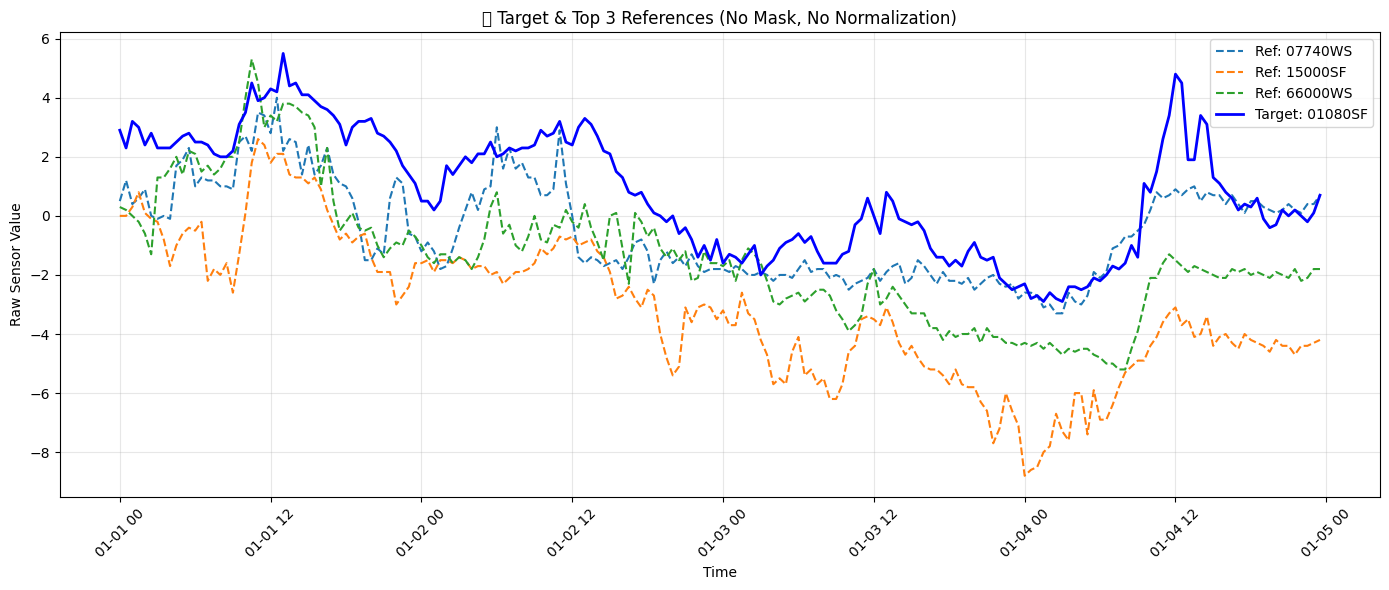

In [124]:
# Define the stations 
target = "01080SF"  # Target station
# References are the top 3 correlated stations
references = ["07740WS","15000SF","66000WS"]

# Define time range for plot (e.g., Jan 1 to Jan 4, 2023)
start_time = "2023-01-01"
end_time = "2023-01-04"

# Slice the DataFrame
plot_df = pattern_df[[target] + references].loc[start_time:end_time].copy()

# Plotting
plt.figure(figsize=(14, 6))

# Plot reference series
for ref in references:
    plt.plot(plot_df.index, plot_df[ref], linestyle='--', label=f"Ref: {ref}")

# Plot target series
plt.plot(plot_df.index, plot_df[target], color='blue', linewidth=2, label=f"Target: {target}")

plt.xlabel("Time")
plt.ylabel("Raw Sensor Value")
plt.title("📍 Target & Top 3 References (No Mask, No Normalization)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [125]:
pattern_df.isnull().sum()

station_code
01080SF    0
07740WS    0
15000SF    0
66000WS    0
dtype: int64

In [126]:
# Get rows where '02500MS' is NaN
# nan_rows = pattern_df[pattern_df['02500MS'].isnull()]
# print(nan_rows)

In [127]:
# # Check for empty strings in '02500MS'
# empty_strings = pattern_df[pattern_df['02500MS'] == ""]
# print(empty_strings)

# # Check for other placeholders (e.g., "NA")
# placeholder_na = pattern_df[pattern_df['02500MS'] == "NA"]
# print(placeholder_na)

In [128]:
# pattern_df = pattern_df.dropna()

In [129]:
pattern_df.isnull().sum()

station_code
01080SF    0
07740WS    0
15000SF    0
66000WS    0
dtype: int64

# -------------------------------------------
# 🔹 STEP 1: Normalizing the Time Series Data
# -------------------------------------------

In [130]:
from sklearn.preprocessing import StandardScaler

# 1️⃣ Initialize the Scaler
scaler = StandardScaler()

# 2️⃣ Fit the scaler on the full pattern_df and transform it
normalized_array = scaler.fit_transform(pattern_df)

# 3️⃣ Reconstruct a DataFrame with the same shape, columns, and index
normalized_df = pd.DataFrame(
    normalized_array,
    columns=pattern_df.columns,
    index=pattern_df.index
)

# 4️⃣ Print shape and preview
print("✅ Normalized shape:", normalized_df.shape)
display(normalized_df.head())


✅ Normalized shape: (14591, 4)


station_code,01080SF,07740WS,15000SF,66000WS
timestamp,,,,
2023-01-01 00:00:00,1.097980,0.695222,1.401801,1.052163
2023-01-01 00:30:00,0.978235,0.833345,1.401801,1.032494
2023-01-01 01:00:00,1.157852,0.675490,1.461425,0.993156
2023-01-01 01:30:00,1.117937,0.714954,1.560798,0.953818
2023-01-01 02:00:00,0.998193,0.774149,1.421676,0.875143


# ---------------------------------------------------------
# 🔹 STEP 2: Define function to inject single-missing in the end
# ---------------------------------------------------------

In [131]:


#  Inject Random Individual Points in the End Region
def inject_single_point_end(series: pd.Series, missing_ratio: float = 0.1, end_fraction: float = 0.25, random_state: int = 42) -> Tuple[pd.Series, np.ndarray, np.ndarray]:
    """
    Inject NaNs randomly in the end portion of the time series.

    Parameters:
        series (pd.Series): Original complete time series.
        missing_ratio (float): Proportion of values to mask (default = 0.1).
        end_fraction (float): Fraction from the end to consider for missingness (default = 0.25).
        random_state (int): Seed for reproducibility.

    Returns:
        masked_series (pd.Series): Series with injected NaNs.
        missing_indices (np.ndarray): Indices where NaNs were inserted.
        true_values (np.ndarray): Original values at those indices.
    """
    ts = series.copy()
    n = len(ts)
    end_start = int(n * (1 - end_fraction))
    candidate_indices = np.arange(end_start, n)
    n_missing = int(len(candidate_indices) * missing_ratio)

    np.random.seed(random_state)
    missing_indices = np.random.choice(candidate_indices, size=n_missing, replace=False)
    true_values = ts.iloc[missing_indices].values

    ts.iloc[missing_indices] = np.nan
    return ts, missing_indices, true_values


# ---------------------------------------------------------
# 🔹 STEP 2b: Apply single-point missing injection at the end of the target series
# ---------------------------------------------------------

In [132]:


#  Define the target station 
target_station = "01080SF"

#  Inject missing values into the middle portion of the series
masked_target_series, missing_idx_array, true_values_array = inject_single_point_end(
    normalized_df[target_station], 
    missing_ratio=0.10  # 10% of the middle portion will be masked
)

# 3 Print sample information about the injected points
print(" Injected missing indices:", missing_idx_array[:5])
print(" True values at those indices:", true_values_array[:5])
print(" Corresponding timestamps:", normalized_df.index[missing_idx_array[:5]])



 Injected missing indices: [12349 14540 14588 14172 14056]
 True values at those indices: [ 0.15998199  0.57908737  0.17993939 -2.19499108 -2.01537449]
 Corresponding timestamps: DatetimeIndex(['2024-11-15 07:30:00', '2024-12-30 23:00:00',
               '2024-12-31 23:00:00', '2024-12-23 07:00:00',
               '2024-12-20 21:00:00'],
              dtype='datetime64[ns]', name='timestamp', freq=None)


# ---------------------------------------------------------
# 🔹 STEP 3: Prepare NumPy arrays for imputation and evaluation
# ---------------------------------------------------------

In [133]:

#  Extract the reference station names (excluding the target)
reference_stations = [col for col in normalized_df.columns if col != target_station]

#  Get reference matrix as shape (num_refs, time) — transposed
ref_matrix = normalized_df[reference_stations].to_numpy().T  # shape: (num_refs, time)

#  Get the masked target series as array (shape: time,)
masked_target_array = masked_target_series.to_numpy().copy()

#  Get the original (true) unmasked target series
true_target_array = normalized_df[target_station].to_numpy()

#  Get the indices of missing values
missing_indices = np.where(np.isnan(masked_target_array))[0]
true_vals = true_target_array[missing_indices]

#  Preview shapes and sanity check
print(" Target shape:", masked_target_array.shape)
print(" Ref matrix shape:", ref_matrix.shape)
print(" Missing indices (preview):", missing_indices[:5])
print(" True values at missing indices (preview):", true_vals[:5])


 Target shape: (14591,)
 Ref matrix shape: (3, 14591)
 Missing indices (preview): [10960 10969 10973 10975 10976]
 True values at missing indices (preview): [1.03810754 1.01815014 0.75870396 0.61900216 0.55912997]


# -----------------------------------------------
# 🔹 STEP 4.1: Set safe parameters for all models
# -----------------------------------------------

In [134]:
k = 5  # Number of top matching sequences (for TKCM-based methods)
l = 7  # Sliding window size for pattern matching (should be ≤ sequence length)

# 🧠 For matrix factorization-based methods (e.g., SVD, TRMF)
# Set a safe low-rank approximation based on the number of reference series
num_references = ref_matrix.shape[0]
rank = max(1, min(num_references - 1, 5))  # Adjust max value as needed


### --- Basic Imputers --

In [135]:
from sklearn.impute import SimpleImputer

# --- 🔹 Zero Imputer ---
class ZeroImputer:
    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        X = X.copy()
        X[np.isnan(X)] = 0
        return X


# --- 🔹 Min Imputer ---
class MinImputer:
    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        fill_value = np.nanmin(X[~np.isnan(X)])  # Minimum of non-NaN values
        imp = SimpleImputer(strategy='constant', fill_value=fill_value)
        return imp.fit_transform(X)


# --- 🔹 Linear Interpolation Imputer ---
class InterpolationImputer:
    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        # Convert to DataFrame for pandas interpolation, then convert back
        return pd.DataFrame(X).interpolate(
            method='linear', axis=0, limit_direction='both'
        ).values


# -----------------------------------------------
# 🔹 STEP 4.2: Apply each model with correct usage
# -----------------------------------------------

In [136]:
# 🧱 Stack the masked target (first row) + full reference matrix (rest)
X_stacked = np.vstack([masked_target_array, ref_matrix])  # Shape: (1 + num_refs, time)

# -------------------
# 🔹 TKCM-based Methods
# -------------------

# 1️⃣ TKCM
tkcm_model = TKCM(k=k, l=l)
tkcm_imputed = masked_target_array.copy()
for offset in missing_indices:
    tkcm_imputed = tkcm_model.impute(tkcm_imputed, offset=offset, ref_ts=ref_matrix)

# 2️⃣ TKCM_PLUS
tkcm_plus_model = TKCM_PLUS(k=k, l=l, alpha=0.5, beta=0.1)
tkcm_plus_imputed = masked_target_array.copy()
for offset in missing_indices:
    tkcm_plus_imputed = tkcm_plus_model.impute(tkcm_plus_imputed, offset=offset, ref_ts=ref_matrix)

# 3️⃣ TKCM_Weighted
tkcm_weighted_model = TKCM_Weighted(k=k, l=l)
tkcm_weighted_imputed = masked_target_array.copy()
for offset in missing_indices:
    tkcm_weighted_imputed = tkcm_weighted_model.impute(tkcm_weighted_imputed, offset=offset, ref_ts=ref_matrix)

# 4️⃣ TKCM_PRO
tkcm_pro_model = TKCM_PRO(k=k, l=l)
tkcm_pro_imputed = masked_target_array.copy()
for offset in missing_indices:
    tkcm_pro_imputed = tkcm_pro_model.impute(tkcm_pro_imputed, offset=offset, ref_ts=ref_matrix)

# --------------------------
# 🔹 Matrix Factorization Models
# --------------------------

# 5️⃣ CDRec
cdrec = CDRec(rank=rank)
cdrec_imputed = cdrec.impute(X_stacked.copy())[0]  # Target is first row

# 6️⃣ DynaMMo
dynammo = DynaMMo(latent_dim=rank)
dynammo_imputed = dynammo.fit_transform(X_stacked.copy())[0]

# 7️⃣ SoftImpute
soft = SoftImpute(max_rank=rank)
soft_imputed = soft.fit_transform(X_stacked.copy())[0]

# 8️⃣ IterativeSVD
svd = IterativeSVD(rank=rank)
svd_imputed = svd.fit_transform(X_stacked.copy())[0]

# 9️⃣ ST_MVL
st_mvl = ST_MVL()
st_mvl_imputed = st_mvl.impute(X_stacked.copy())[0]

# 🔟 TRMF
trmf = TRMFImputer(rank=rank)
trmf_imputed = trmf.fit_transform(X_stacked.copy())[0]

# --------------------
# 🔹 Simple Baseline Models
# --------------------

# 1️⃣1️⃣ Zero Imputer
zero_imputer = ZeroImputer()
zero_imputed = zero_imputer.fit_transform(X_stacked.copy())[0]

# 1️⃣2️⃣ Min Imputer
min_imputer = MinImputer()
min_imputed = min_imputer.fit_transform(X_stacked.copy())[0]

# 1️⃣3️⃣ Interpolation Imputer
interp_imputer = InterpolationImputer()
interp_imputed = interp_imputer.fit_transform(X_stacked.copy())[0]


# -----------------------------------------------
# 🔹 STEP 5: Define evaluation function (pointwise)
# -----------------------------------------------

In [137]:
results_point = []

def evaluate_pointwise(name: str, imputed_array: np.ndarray, true_values: np.ndarray, missing_indices: np.ndarray):
    """
    Evaluate a single imputed array against true values at known missing indices.
    
    Appends result to global list `results_point`.
    """
    try:
        predicted_vals = imputed_array[missing_indices]
        
        if np.any(np.isnan(predicted_vals)):
            raise ValueError("Contains NaN in imputed values")
        
        errors = predicted_vals - true_values
        mae = np.mean(np.abs(errors))
        rmse = np.sqrt(np.mean(errors ** 2))
        
        results_point.append({
            "Method": name,
            "Missing Points": len(missing_indices),
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4)
        })
    
    except Exception as e:
        print(f"❌ {name} failed: {e}")
        results_point.append({
            "Method": name,
            "Missing Points": len(missing_indices),
            "MAE": "NaN",
            "RMSE": "NaN"
        })


# -----------------------------------------------
# 🔹 STEP 6: Apply ST_MVL and Evaluate
# -----------------------------------------------

In [138]:
# Step 1: Stack masked target + reference
X_stmv = np.vstack([masked_target_array, ref_matrix])  # Shape: (1 + num_refs, time)

# Step 2: Clean reference rows by replacing NaNs with zeros (only in reference series)
X_stmv[1:, :] = np.nan_to_num(X_stmv[1:, :])  # Target row keeps NaNs

# Step 3: Run ST_MVL imputation and evaluate
try:
    st_mvl_model = ST_MVL()
    st_mvl_imputed = st_mvl_model.impute(X_stmv)[0]  # Imputed target is first row
    evaluate_pointwise("ST_MVL", st_mvl_imputed, true_vals, missing_indices)

except Exception as e:
    print(f"❌ ST_MVL failed: {e}")
    fallback = np.full_like(masked_target_array, np.nan)
    evaluate_pointwise("ST_MVL", fallback, true_vals, missing_indices)


# -----------------------------------------------
# 🔹 STEP 7: Apply TRMF and Evaluate
# -----------------------------------------------

In [139]:
# Step 1: Prepare TRMF input  (shape: time × features)
# - First column = masked target
# - Remaining columns = reference series
X_trmf_input = np.vstack([masked_target_array, ref_matrix]).T.copy()   # (time, 1+num_refs)

# Step 2: Create observation mask and fill NaNs with zeros
observed_mask = ~np.isnan(X_trmf_input)
X_trmf_input = np.nan_to_num(X_trmf_input, nan=0.0).astype(np.float64)

# Step 3: Fit TRMF and transform
try:
    trmf_model = TRMFImputer(rank=rank, lag_idx=[1, 2, 3])
    trmf_model.fit(X_trmf_input, observed_mask)
    X_trmf_output = trmf_model.transform()

    # Extract imputed target (first column)
    trmf_imputed = X_trmf_output[:, 0]
    evaluate_pointwise("TRMF", trmf_imputed, true_vals, missing_indices)

except Exception as e:
    print(f"❌ TRMF failed: {e}")
    fallback = np.full_like(masked_target_array, np.nan)
    evaluate_pointwise("TRMF", fallback, true_vals, missing_indices)


# -----------------------------------------------
# 🔹 STEP 8: Evaluate All Methods (TKCM + Baselines)
# -----------------------------------------------

In [140]:
#  TKCM Variants — loop over all, support multiple missing
for method_name, model in {
    "TKCM": TKCM(k=k, l=l),
    "TKCM_PLUS": TKCM_PLUS(k=k, l=l, alpha=0.5, beta=0.5),
    "TKCM_Weighted": TKCM_Weighted(k=k, l=l),
    "TKCM_PRO": TKCM_PRO(k=k, l=l),
}.items():
    try:
        # Impute missing values one-by-one
        imputed_array = masked_target_array.copy()
        for offset in missing_indices:
            imputed_array = model.impute(imputed_array, offset=offset, ref_ts=ref_matrix)

        evaluate_pointwise(method_name, imputed_array, true_vals, missing_indices)

    except Exception as e:
        print(f"❌ {method_name} failed:", e)
        fallback = np.full_like(masked_target_array, np.nan)
        evaluate_pointwise(method_name, fallback, true_vals, missing_indices)


#  Baseline + Matrix Factorization Models — use precomputed outputs
baseline_models = {
    "CDRec": cdrec_imputed,
    "DynaMMo": dynammo_imputed,
    "SoftImpute": soft_imputed,
    "SVDImpute": svd_imputed,
    "Zero": zero_imputed,
    "Min": min_imputed,
    "Interpolation": interp_imputed,
    "ST_MVL": st_mvl_imputed,
    "TRMF": trmf_imputed,
}

#  Evaluate all baseline methods
for name, imputed_array in baseline_models.items():
    evaluate_pointwise(name, imputed_array, true_vals, missing_indices)


#  Final Results Table
results_df = pd.DataFrame(results_point)
display(results_df.style.background_gradient(cmap="YlGnBu", subset=["MAE", "RMSE"]))


,Method,Missing Points,MAE,RMSE
0,ST_MVL,364,0.216600,0.281300
1,TRMF,364,0.642000,0.779200
2,TKCM,364,0.203400,0.268500
3,TKCM_PLUS,364,0.734100,0.985200
4,TKCM_Weighted,364,0.207100,0.281100
5,TKCM_PRO,364,1.914900,2.334600
6,CDRec,364,0.180100,0.225200
7,DynaMMo,364,0.178800,0.224200
8,SoftImpute,364,0.177600,0.221500
9,SVDImpute,364,0.179500,0.225100


| Rank | Method             | Missing Points | MAE        | RMSE       |
| ---- | ------------------ | -------------- | ---------- | ---------- |
| ✅ 1  | **TKCM\_Weighted** | 364            | **0.3252** | **0.4233** |
| 2    | TKCM               | 364            | 0.3273     | 0.4251     |
| 3    | SoftImpute         | 364            | 0.3510     | 0.4360     |
| 4    | DynaMMo            | 364            | 0.3520     | 0.4392     |
| 5    | CDRec              | 364            | 0.3523     | 0.4404     |
| 6    | SVDImpute          | 364            | 0.3523     | 0.4405     |
| 7    | Interpolation      | 364            | 0.4261     | 0.5396     |
| 8    | ST\_MVL            | 364            | 0.4779     | 0.6231     |
| 9    | TKCM\_PLUS         | 364            | 0.4996     | 0.6879     |
| 10   | TRMF               | 364            | 0.5553     | 0.6973     |
| 11   | Zero               | 364            | 0.7786     | 0.9602     |
| 12   | TKCM\_PRO          | 364            | 1.5760     | 1.8536     |
| 13   | Min                | 364            | 2.5754     | 2.7464     |


# ----------------------------------------------------
# 🔍 STEP 9: Grid Search for TKCM and TKCM_Weighted (pointwise)
# ----------------------------------------------------


In [141]:
# k_values = [3, 5, 7, 8, 10, 12]
# l_values = [3, 4, 5, 6, 8, 10]

# grid_results = []

# # Use masked_target_array, ref_matrix, missing_indices, true_vals from earlier
# for method_class, method_name in [
#     (TKCM, "TKCM"),
#     (TKCM_Weighted, "TKCM_Weighted"),
# ]:
#     for k in k_values:
#         for l in l_values:
#             try:
#                 # Impute missing points one-by-one
#                 imputed = masked_target_array.copy()
#                 model = method_class(k=k, l=l)

#                 for offset in missing_indices:
#                     imputed = model.impute(imputed, offset=offset, ref_ts=ref_matrix)

#                 predicted_vals = imputed[missing_indices]
#                 if np.any(np.isnan(predicted_vals)):
#                     raise ValueError("NaN in imputed values")

#                 mae = np.mean(np.abs(predicted_vals - true_vals))
#                 rmse = np.sqrt(np.mean((predicted_vals - true_vals) ** 2))

#                 grid_results.append({
#                     "Method": method_name,
#                     "k": k,
#                     "l": l,
#                     "MAE": round(mae, 4),
#                     "RMSE": round(rmse, 4)
#                 })

#             except Exception as e:
#                 print(f"❌ Grid failed: {method_name} (k={k}, l={l}):", e)
#                 grid_results.append({
#                     "Method": method_name,
#                     "k": k,
#                     "l": l,
#                     "MAE": "ERROR",
#                     "RMSE": "ERROR"
#                 })

# # --------------------------------------------------
# # 📊 STEP 10: Show Best Configs from Grid Search
# # --------------------------------------------------

# grid_df = pd.DataFrame(grid_results)

# # Remove rows with errors before sorting
# grid_df_clean = grid_df[(grid_df["MAE"] != "ERROR") & (grid_df["RMSE"] != "ERROR")].copy()
# grid_df_clean[["MAE", "RMSE"]] = grid_df_clean[["MAE", "RMSE"]].apply(pd.to_numeric)

# # ✅ Display sorted results (best MAE first)
# display(grid_df_clean.sort_values(by=["MAE", "RMSE"]).style.set_caption("Grid Search Results (Pointwise Imputation)"))


### -----------------------------------------------
### 🔹 STEP 11: Get Best Configs for Each Model
### -----------------------------------------------

In [142]:


# # Filter best (lowest MAE) config for each method
# best_tkcm = grid_df_clean[grid_df_clean["Method"] == "TKCM"].nsmallest(1, "MAE")
# best_weighted = grid_df_clean[grid_df_clean["Method"] == "TKCM_Weighted"].nsmallest(1, "MAE")

# # ✅ Print summary of best configurations
# print("✅ Best TKCM Config →", best_tkcm[["k", "l", "MAE", "RMSE"]].values[0])
# print("✅ Best TKCM_Weighted Config →", best_weighted[["k", "l", "MAE", "RMSE"]].values[0])


# -----------------------------------------------
# 🔹 STEP 12: Grid Search for TKCM_PLUS (α–β combinations)
# -----------------------------------------------

In [143]:
alphas = [0.2, 0.5, 0.8]
betas = [0.2, 0.5, 0.8]

# Only consider combinations where α + β ≈ 1 (tolerance = 0.1)
valid_combinations = [(a, b) for a in alphas for b in betas if abs(a + b - 1.0) <= 0.1]

# Store results
plus_grid_results = []

# Loop over valid combinations
for alpha, beta in tqdm(valid_combinations, desc="Searching (α, β)", unit="combo"):
    try:
        imputed = masked_target_array.copy()
        model = TKCM_PLUS(k=k, l=l, alpha=alpha, beta=beta)
        
        for offset in missing_indices:
            imputed = model.impute(imputed, offset=offset, ref_ts=ref_matrix)

        predicted_vals = imputed[missing_indices]
        if np.any(np.isnan(predicted_vals)):
            raise ValueError("NaN in imputed values")

        mae = np.mean(np.abs(predicted_vals - true_vals))
        rmse = np.sqrt(np.mean((predicted_vals - true_vals) ** 2))

        plus_grid_results.append({
            "Method": "TKCM_PLUS",
            "Alpha": alpha,
            "Beta": beta,
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4),
            "Missing Points": len(missing_indices)
        })

    except Exception as e:
        print(f"❌ TKCM_PLUS failed for α={alpha}, β={beta}: {e}")
        plus_grid_results.append({
            "Method": "TKCM_PLUS",
            "Alpha": alpha,
            "Beta": beta,
            "MAE": "ERROR",
            "RMSE": "ERROR",
            "Missing Points": len(missing_indices)
        })

# -----------------------------------------------
# 📊 STEP 13: Analyze α–β Grid Results
# -----------------------------------------------

# Convert to DataFrame
plus_df = pd.DataFrame(plus_grid_results)

# Clean and sort
plus_df_clean = plus_df[(plus_df["MAE"] != "ERROR") & (plus_df["RMSE"] != "ERROR")].copy()
plus_df_clean[["MAE", "RMSE"]] = plus_df_clean[["MAE", "RMSE"]].apply(pd.to_numeric)

# ✅ Display best α–β configs sorted by MAE
display(plus_df_clean.sort_values(by=["MAE", "RMSE"]).style.set_caption("TKCM_PLUS α–β Grid Search Results"))


Searching (α, β): 100%|██████████| 3/3 [07:36<00:00, 152.22s/combo]


,Method,Alpha,Beta,MAE,RMSE,Missing Points
2,TKCM_PLUS,0.800000,0.200000,0.405600,0.587600,364
1,TKCM_PLUS,0.500000,0.500000,0.734100,0.985200,364
0,TKCM_PLUS,0.200000,0.800000,0.842400,1.065300,364


# -----------------------------------------------
# 🔹 STEP 14: Extract Best TKCM_PLUS Config (α–β)
# -----------------------------------------------

In [144]:


# Get the row with the smallest MAE
best_plus = plus_df_clean.nsmallest(1, "MAE")

# ✅ Print best configuration values
print("✅ Best TKCM_PLUS Config →", best_plus[["Alpha", "Beta", "MAE", "RMSE"]].values[0])


✅ Best TKCM_PLUS Config → [0.8    0.2    0.4056 0.5876]


# -----------------------------------------------
# 🔹 STEP 15: Robust TKCM_PRO with Pearson Filtering
# -----------------------------------------------

In [145]:


def run_tkcm_pro_robust_real(k_vals, threshold, masked_target_array, true_target_array, ref_matrix, missing_indices, true_vals):
    """
    Run a robust variant of TKCM_PRO using Pearson-based reference filtering.

    Parameters:
        k_vals (list[int]): List of k-values to test (kept for compatibility).
        threshold (float): Minimum Pearson correlation to consider a reference series.
        masked_target_array (np.ndarray): Target series with missing values.
        true_target_array (np.ndarray): Full target series (no NaNs).
        ref_matrix (np.ndarray): Reference series matrix (num_refs × time).
        missing_indices (np.ndarray): Index positions where values are missing.
        true_vals (np.ndarray): Ground truth values at missing positions.

    Returns:
        pd.DataFrame: Sorted DataFrame with MAE and RMSE results.
    """
    results = []

    for k in k_vals:
        try:
            # Step 1: Compute Pearson correlations
            pearson_corrs = [np.corrcoef(true_target_array, ref)[0, 1] for ref in ref_matrix]

            # Step 2: Select references above the threshold
            selected_indices = [i for i, corr in enumerate(pearson_corrs) if corr >= threshold]

            # Step 3: Filter reference matrix (fallback to at least one series)
            filtered_refs = ref_matrix[selected_indices, :] if selected_indices else ref_matrix[:1, :]

            # Step 4: Impute by mean of selected references at missing indices
            imputed = masked_target_array.copy()
            for offset in missing_indices:
                values = filtered_refs[:, offset]
                if np.all(np.isnan(values)):
                    continue  # Leave as NaN
                imputed[offset] = np.nanmean(values)

            # Step 5: Evaluate
            predicted = imputed[missing_indices]
            mae = np.mean(np.abs(predicted - true_vals))
            rmse = np.sqrt(np.mean((predicted - true_vals) ** 2))

            results.append({
                "Method": "TKCM_PRO_Robust",
                "k": k,
                "Threshold": threshold,
                "Anchors Used": len(selected_indices),
                "MAE": round(mae, 4),
                "RMSE": round(rmse, 4)
            })

        except Exception as e:
            print(f"❌ TKCM_PRO_Robust failed at k={k}, threshold={threshold}: {e}")
            results.append({
                "Method": "TKCM_PRO_Robust",
                "k": k,
                "Threshold": threshold,
                "Anchors Used": "ERROR",
                "MAE": "ERROR",
                "RMSE": "ERROR"
            })

    # Convert to DataFrame
    df = pd.DataFrame(results)

    # Clean and return sorted result
    df_clean = df[df["MAE"] != "ERROR"].copy()
    df_clean[["MAE", "RMSE"]] = df_clean[["MAE", "RMSE"]].apply(pd.to_numeric)

    return df_clean.sort_values(by=["MAE", "RMSE"])


# -----------------------------------------------
# 🔹 STEP 16: Run TKCM_PRO_Robust and Display Results
# -----------------------------------------------

In [146]:


k_values = [3, 5, 7, 9, 12]
threshold = 0.7  # Try also: 0.8 or 0.9 for stricter anchor selection

# Run the robust variant with Pearson-based anchor filtering
tkcm_pro_robust_df = run_tkcm_pro_robust_real(
    k_vals=k_values,
    threshold=threshold,
    masked_target_array=masked_target_array,
    true_target_array=true_target_array,
    ref_matrix=ref_matrix,
    missing_indices=missing_indices,
    true_vals=true_vals
)

# ✅ Display sorted results
display(tkcm_pro_robust_df.style.set_caption("✅ TKCM_PRO Robustified Results (Pearson Threshold Filtering)"))


,Method,k,Threshold,Anchors Used,MAE,RMSE
0,TKCM_PRO_Robust,3,0.700000,3,0.171500,0.217200
1,TKCM_PRO_Robust,5,0.700000,3,0.171500,0.217200
2,TKCM_PRO_Robust,7,0.700000,3,0.171500,0.217200
3,TKCM_PRO_Robust,9,0.700000,3,0.171500,0.217200
4,TKCM_PRO_Robust,12,0.700000,3,0.171500,0.217200


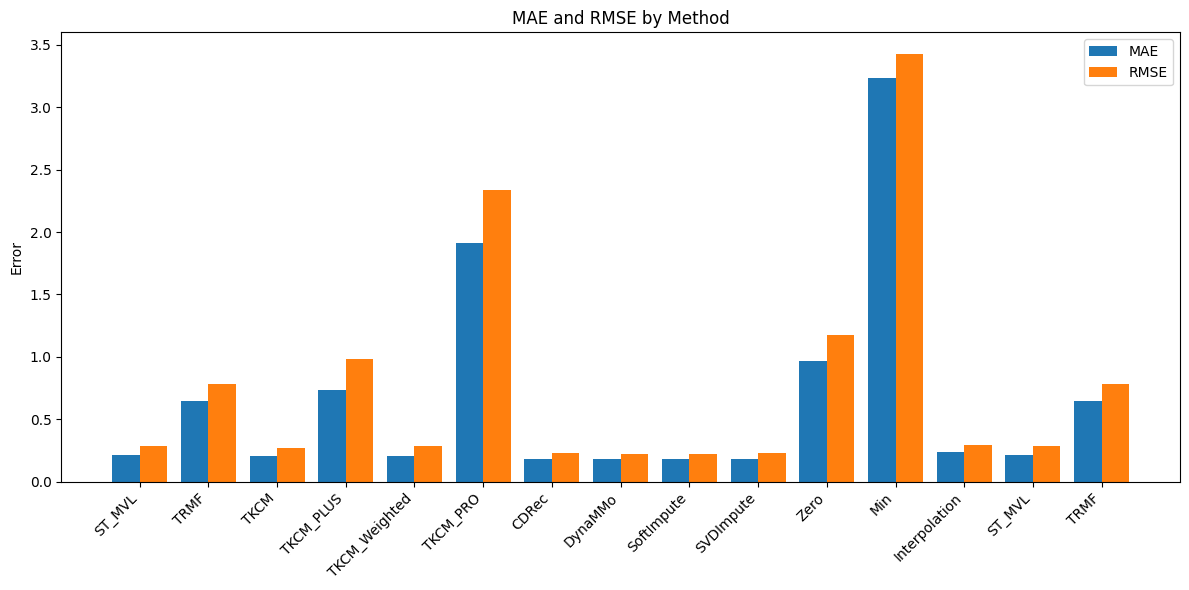

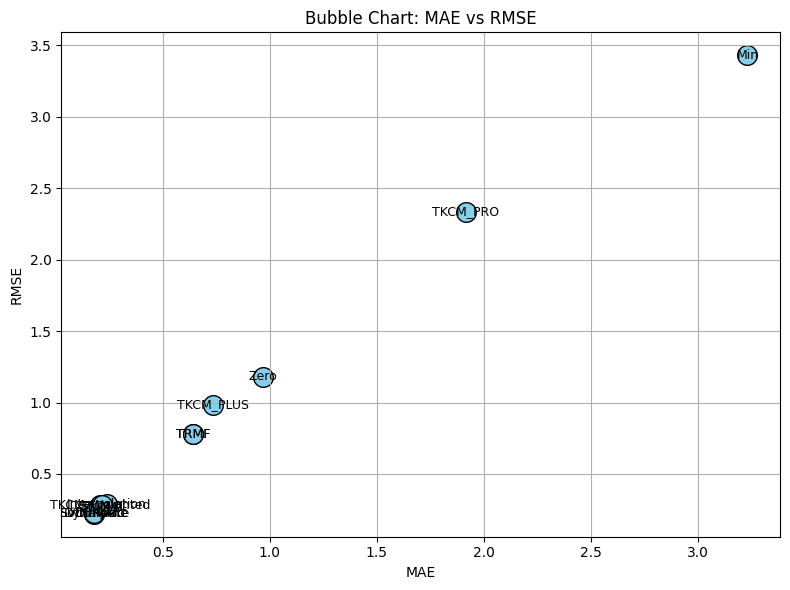

In [147]:

# -----------------------------------------------
# 🔹 STEP 21.1: Convert and Clean results_point for Plotting
# -----------------------------------------------

results_df = pd.DataFrame(results_point)

# Keep only valid numeric entries
plot_df = results_df[(results_df["MAE"] != "NaN") & (results_df["RMSE"] != "NaN")].copy()
plot_df["MAE"] = pd.to_numeric(plot_df["MAE"])
plot_df["RMSE"] = pd.to_numeric(plot_df["RMSE"])

# -----------------------------------------------
# 📊 STEP 21.2: Bar Plot — MAE & RMSE per Method
# -----------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.4
x = range(len(plot_df))

# Plot MAE and RMSE side by side
ax.bar([i - bar_width/2 for i in x], plot_df["MAE"], width=bar_width, label="MAE")
ax.bar([i + bar_width/2 for i in x], plot_df["RMSE"], width=bar_width, label="RMSE")

# Format axes
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Method"], rotation=45, ha="right")
ax.set_ylabel("Error")
ax.set_title("MAE and RMSE by Method")
ax.legend()

plt.tight_layout()
plt.show()

# -----------------------------------------------
# 🔵 STEP 21.3: Bubble Chart — MAE vs RMSE
# -----------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    plot_df["MAE"], plot_df["RMSE"],
    s=200, c='skyblue', edgecolors='black'
)

# Annotate each point with the method name
for i, row in plot_df.iterrows():
    ax.annotate(row["Method"], (row["MAE"], row["RMSE"]),
                fontsize=9, ha='center', va='center')

ax.set_xlabel("MAE")
ax.set_ylabel("RMSE")
ax.set_title("Bubble Chart: MAE vs RMSE")
ax.grid(True)

plt.tight_layout()
plt.show()


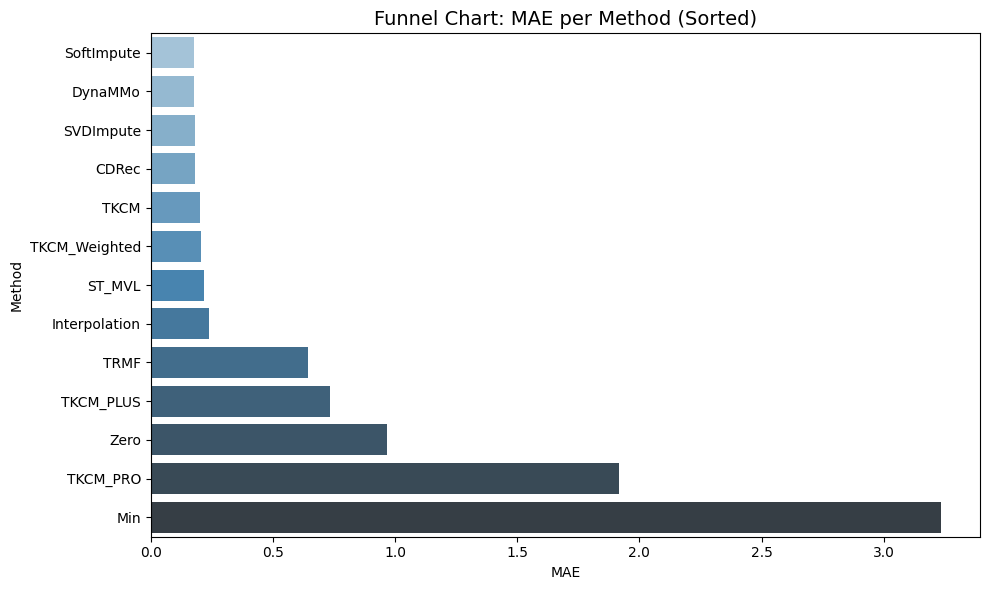

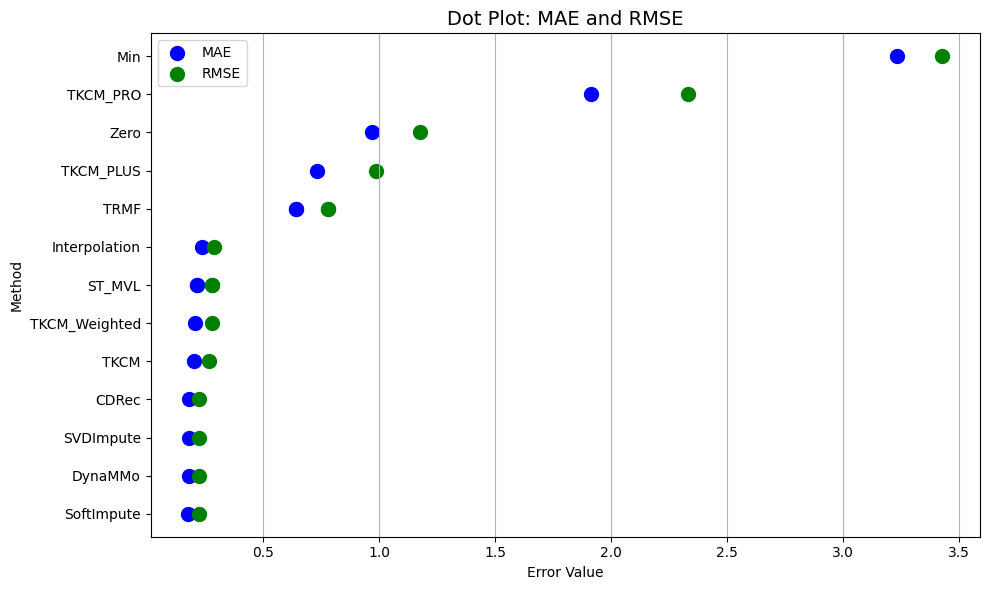

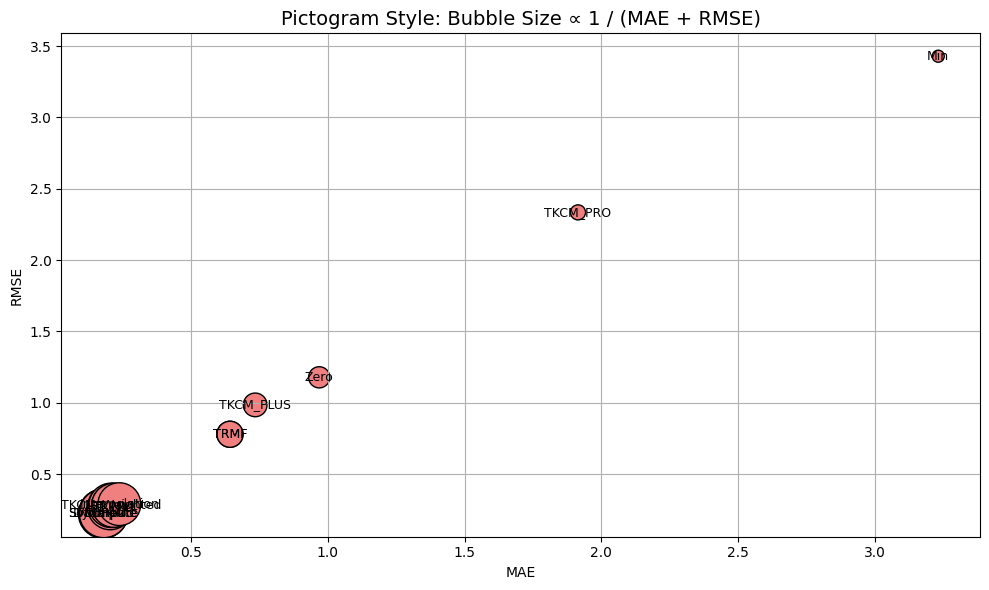

In [148]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# -----------------------------------------------
# 🔹 STEP 22.1: Prepare Data for Plotting
# -----------------------------------------------

# Use and clean existing results
plot_df = results_df[(results_df["MAE"] != "NaN") & (results_df["RMSE"] != "NaN")].copy()
plot_df["MAE"] = pd.to_numeric(plot_df["MAE"])
plot_df["RMSE"] = pd.to_numeric(plot_df["RMSE"])

# Sort by MAE for visual consistency
plot_df = plot_df.sort_values("MAE").reset_index(drop=True)

# -----------------------------------------------
# 📉 STEP 22.2: Funnel Chart — MAE Sorted
# -----------------------------------------------

plt.figure(figsize=(10, 6))
sns.barplot(x="MAE", y="Method", data=plot_df, palette="Blues_d")
plt.title("Funnel Chart: MAE per Method (Sorted)", fontsize=14)
plt.xlabel("MAE")
plt.ylabel("Method")
plt.tight_layout()
plt.show()

# -----------------------------------------------
# 🎯 STEP 22.3: Dot Plot — MAE & RMSE Together
# -----------------------------------------------

plt.figure(figsize=(10, 6))
plt.scatter(plot_df["MAE"], plot_df["Method"], label="MAE", color="blue", s=100)
plt.scatter(plot_df["RMSE"], plot_df["Method"], label="RMSE", color="green", s=100)

plt.xlabel("Error Value")
plt.ylabel("Method")
plt.title("Dot Plot: MAE and RMSE", fontsize=14)
plt.legend()
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

# -----------------------------------------------
# 📦 STEP 22.4: Pictogram — Bubble Size ∝ 1 / (MAE + RMSE)
# -----------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

# Larger size = better (lower total error)
sizes = 500 / (plot_df["MAE"] + plot_df["RMSE"])

bubble = ax.scatter(
    plot_df["MAE"], plot_df["RMSE"],
    s=sizes,
    color='lightcoral',
    edgecolors='black'
)

# Add method names at bubble centers
for i, row in plot_df.iterrows():
    ax.annotate(row["Method"], (row["MAE"], row["RMSE"]), fontsize=9, ha='center', va='center')

ax.set_xlabel("MAE")
ax.set_ylabel("RMSE")
ax.set_title("Pictogram Style: Bubble Size ∝ 1 / (MAE + RMSE)", fontsize=14)
ax.grid(True)
plt.tight_layout()
plt.show()


# -----------------------------------------------
# 🔹 STEP 23: Comparison Chart — MAE vs. RMSE (Bar + Labels)
# -----------------------------------------------

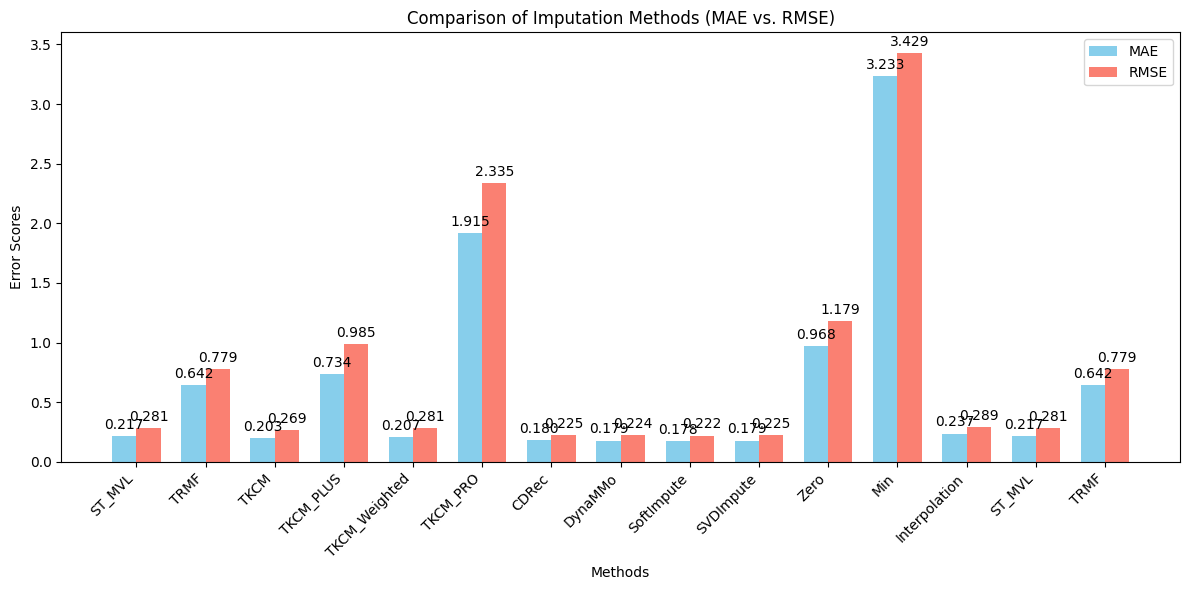

In [149]:


# Filter and convert MAE/RMSE to numeric
plot_df = results_df[(results_df["MAE"] != "NaN") & (results_df["RMSE"] != "NaN")].copy()
plot_df["MAE"] = pd.to_numeric(plot_df["MAE"])
plot_df["RMSE"] = pd.to_numeric(plot_df["RMSE"])

methods = plot_df["Method"]
mae_scores = plot_df["MAE"]
rmse_scores = plot_df["RMSE"]

x = np.arange(len(methods))  # X-axis positions
width = 0.35  # Bar width

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot MAE bars
mae_bars = ax.bar(x - width/2, mae_scores, width, label="MAE", color="skyblue")

# Plot RMSE bars
rmse_bars = ax.bar(x + width/2, rmse_scores, width, label="RMSE", color="salmon")

# Set labels, ticks, and title
ax.set_xlabel("Methods")
ax.set_ylabel("Error Scores")
ax.set_title("Comparison of Imputation Methods (MAE vs. RMSE)")
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=45, ha="right")
ax.legend()

# 🔢 Add labels on top of each bar
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.3f}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # Vertical offset
                    textcoords="offset points",
                    ha="center", va="bottom")

add_labels(mae_bars)
add_labels(rmse_bars)

# Final layout tweak and display
plt.tight_layout()
plt.show()
